<a href="https://colab.research.google.com/github/NULLPX-a/TelecomeX_alura_part2/blob/main/Telecom_X_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importacion de librerias

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv('/content/datos_tratados.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


# Eliminacion de datos irrelevantes


In [ ]:
df.drop(columns='CustomerID', inplace=True)

In [ ]:
for col in df.columns:
  print(f'{col}: \t {df[col].unique()}')
  print('='*60)

Churn: 	 ['No' 'Yes']
Gender: 	 ['Female' 'Male']
SeniorCitizen: 	 ['No' 'Yes']
Partner: 	 ['Yes' 'No']
Dependents: 	 ['Yes' 'No']
Tenure: 	 [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
PhoneService: 	 ['Yes' 'No']
MultipleLines: 	 ['No' 'Yes']
InternetService: 	 ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 	 ['No' 'Yes']
OnlineBackup: 	 ['Yes' 'No']
DeviceProtection: 	 ['No' 'Yes']
TechSupport: 	 ['Yes' 'No']
StreamingTV: 	 ['Yes' 'No']
StreamingMovies: 	 ['No' 'Yes']
Contract: 	 ['One year' 'Month-to-month' 'Two year']
PaperlessBilling: 	 ['Yes' 'No']
PaymentMethod: 	 ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
ChargesDaily: 	 [2.19 2.   2.46 3.27 2.8  2.31 3.66 2.82 1.61 3.02 1.51 3.89 2.3  3.38
 1.5  3.19 2.04 2.4  2.09 0.84 3.14 2.79 0.66 0.68 1.02 3.46 0.65 3.

# Encoding

In [ ]:
if 'Churn' in df.columns:
    y = df['Churn']
    X = df.drop(columns=['Churn'])

    if y.dtype == 'object':
        y = y.map({'Yes': 1, 'No': 0})
else:
    raise ValueError("No se encontró la columna 'Churn'. Verifica el nombre de tu columna target.")

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# Normalizar y estandarizar datos

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),

        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

# Análisis de Desbalance de Clases

            Clase  Cantidad  Porcentaje
No Churn (Activo)      5174   73.463013
  Churn (Canceló)      1869   26.536987


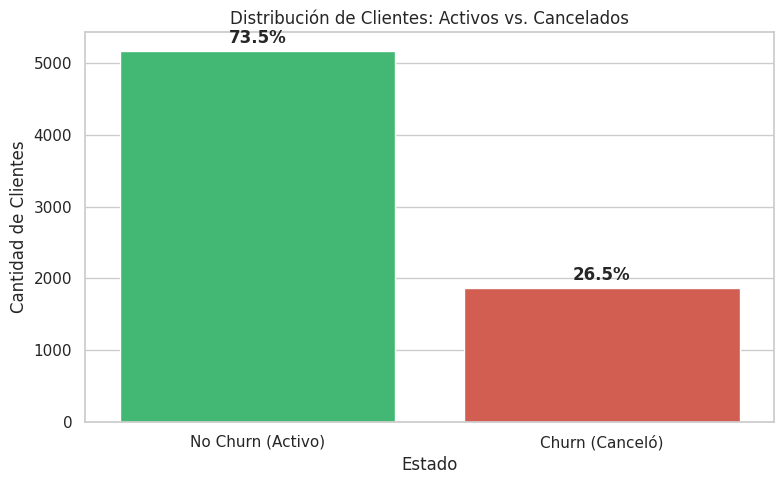


 Ratio de desbalance: 2.77 a 1
 Confirmado: Existe desbalance significativo. Se requerirá SMOTE en el entrenamiento.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

dist = y.value_counts()
porc = y.value_counts(normalize=True) * 100

df_dist = pd.DataFrame({'Clase': dist.index, 'Cantidad': dist.values, 'Porcentaje': porc.values})
df_dist['Clase'] = df_dist['Clase'].map({0: 'No Churn (Activo)', 1: 'Churn (Canceló)'})

print(df_dist.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='Clase', y='Cantidad', data=df_dist, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Clientes: Activos vs. Cancelados')
plt.ylabel('Cantidad de Clientes')
plt.xlabel('Estado')
for i, v in enumerate(dist.values):
    plt.text(i, v + (max(dist.values)*0.02), f'{porc.values[i]:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

ratio = dist[0] / dist[1] if dist[1] > 0 else float('inf')
print(f"\n Ratio de desbalance: {ratio:.2f} a 1")
if ratio > 1.5:
    print(" Confirmado: Existe desbalance significativo. Se requerirá SMOTE en el entrenamiento.")
else:
    print("ℹ El desbalance es leve o nulo.")

# Analisis de Correlacion

  Top 10 Variables con MAYOR correlación positiva con Churn (Riesgo):
InternetService_Fiber optic       0.308
PaymentMethod_Electronic check    0.302
ChargesDaily                      0.193
ChargesMonthly                    0.193
PaperlessBilling_Yes              0.192
SeniorCitizen_Yes                 0.151
StreamingTV_Yes                   0.063
StreamingMovies_Yes               0.061
MultipleLines_Yes                 0.040
PhoneService_Yes                  0.012
Name: Churn, dtype: float64

  Top 10 Variables con MAYOR correlación negativa con Churn (Protección):
PaymentMethod_Credit card (automatic)   -0.134
Partner_Yes                             -0.150
Dependents_Yes                          -0.164
TechSupport_Yes                         -0.165
OnlineSecurity_Yes                      -0.171
Contract_One year                       -0.178
ChargesTotal                            -0.198
InternetService_No                      -0.228
Contract_Two year                       -0.302
Tenu

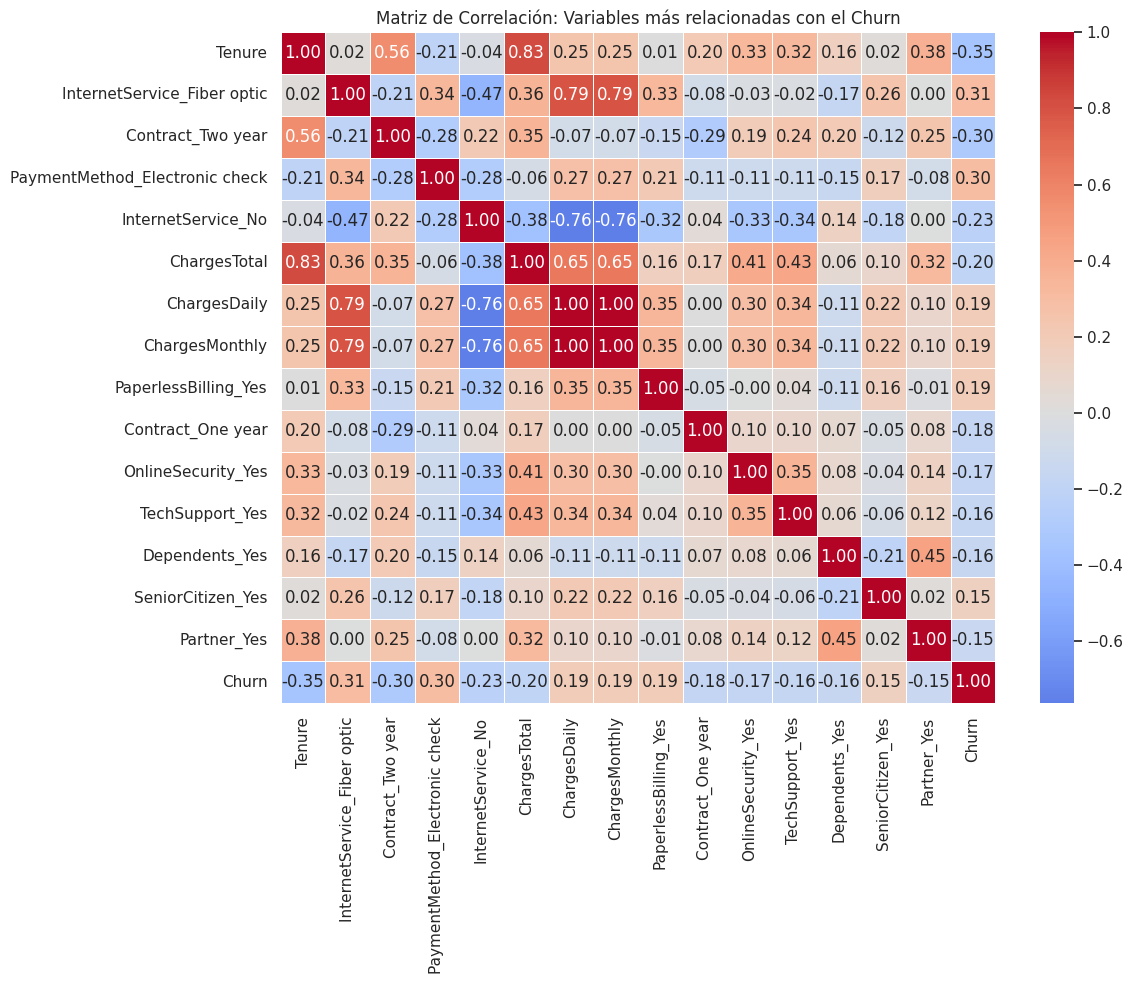


💡 Hallazgo clave:
   - La variable que MÁS empuja al Churn es: 'InternetService_Fiber optic' (0.31)
   - La variable que MÁS protege del Churn es: 'Tenure' (-0.35)


In [ ]:
df_corr = pd.concat([X, y], axis=1).copy()

df_corr_encoded = pd.get_dummies(df_corr, drop_first=True)

corr_matrix = df_corr_encoded.corr()

churn_corrs = corr_matrix['Churn'].drop('Churn').sort_values(ascending=False)

print("  Top 10 Variables con MAYOR correlación positiva con Churn (Riesgo):")
print(churn_corrs.head(10).round(3))

print("\n  Top 10 Variables con MAYOR correlación negativa con Churn (Protección):")
print(churn_corrs.tail(10).round(3))

top_vars = churn_corrs.abs().sort_values(ascending=False).head(15).index.tolist()
top_vars.append('Churn')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix.loc[top_vars, top_vars], annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=.5)
plt.title('Matriz de Correlación: Variables más relacionadas con el Churn')
plt.tight_layout()
plt.show()

max_pos = churn_corrs.idxmax()
max_neg = churn_corrs.idxmin()
print(f"\n💡 Hallazgo clave:")
print(f"   - La variable que MÁS empuja al Churn es: '{max_pos}' ({churn_corrs[max_pos]:.2f})")
print(f"   - La variable que MÁS protege del Churn es: '{max_neg}' ({churn_corrs[max_neg]:.2f})")

# Analisis Dirigido

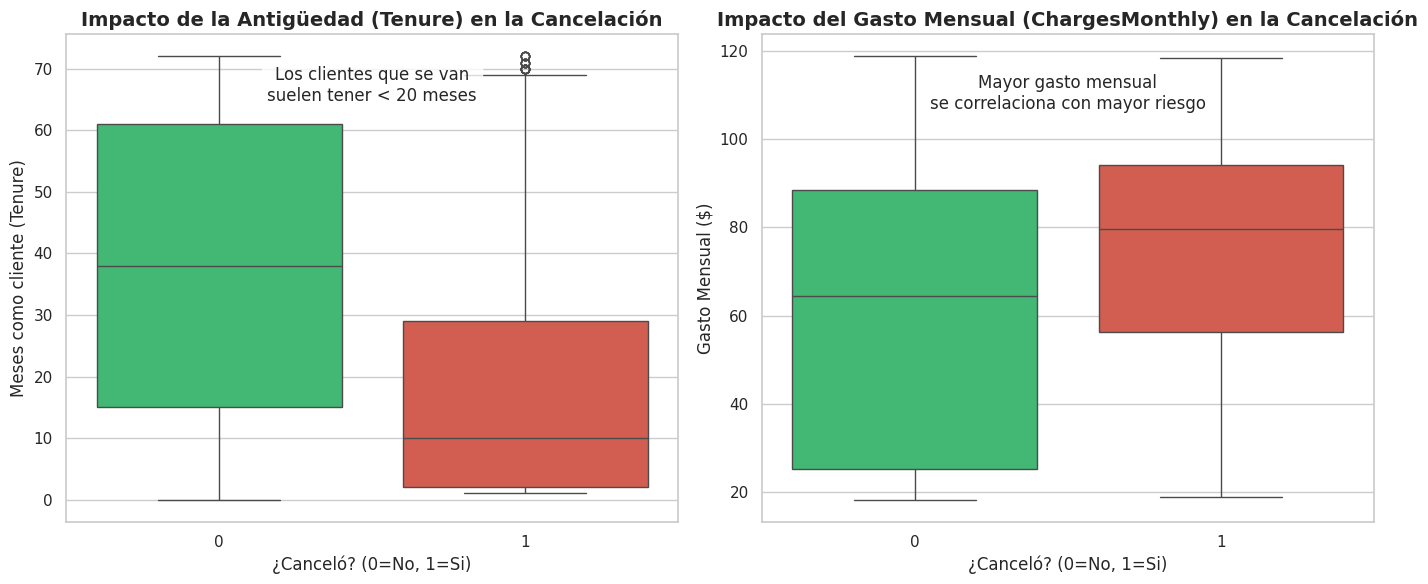

<Figure size 1000x600 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='Churn', y='Tenure', data=pd.concat([X, y], axis=1), ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Impacto de la Antigüedad (Tenure) en la Cancelación', fontsize=14, fontweight='bold')
axes[0].set_xlabel('¿Canceló? (0=No, 1=Si)')
axes[0].set_ylabel('Meses como cliente (Tenure)')
axes[0].text(0.5, max(df['Tenure'])*0.9, 'Los clientes que se van\nsuelen tener < 20 meses',
             ha='center', bbox=dict(facecolor='white', alpha=0.8))

col_gasto = 'ChargesMonthly' if 'ChargesMonthly' in X.columns else 'MonthlyCharges'

if col_gasto in X.columns:
    sns.boxplot(x='Churn', y=col_gasto, data=pd.concat([X, y], axis=1), ax=axes[1], palette=['#2ecc71', '#e74c3c'])
    axes[1].set_title(f'Impacto del Gasto Mensual ({col_gasto}) en la Cancelación', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('¿Canceló? (0=No, 1=Si)')
    axes[1].set_ylabel('Gasto Mensual ($)')
    axes[1].text(0.5, max(X[col_gasto])*0.9, 'Mayor gasto mensual\nse correlaciona con mayor riesgo',
                 ha='center', bbox=dict(facecolor='white', alpha=0.8))
else:
    axes[1].text(0.5, 0.5, f"Columna '{col_gasto}' no encontrada", ha='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
df_viz = pd.concat([X, y], axis=1)


# Separacion de datos

In [ ]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.30
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"División completada (70% Train | 30% Test):")
print(f"   Entrenamiento: {X_train.shape[0]} muestras ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Prueba:        {X_test.shape[0]} muestras ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n🔍 Verificación de estratificación (Proporción de Churn):")
print(f"   Original: {y.mean():.2%}")
print(f"   Train:    {y_train.mean():.2%}")
print(f"   Test:     {y_test.mean():.2%}")

if abs(y_train.mean() - y_test.mean()) < 0.01:
    print("   La distribución de clases se mantuvo consistente en ambos sets.")
else:
    print("   Atención: Hay ligera variación en la distribución.")

División completada (70% Train | 30% Test):
   Entrenamiento: 4930 muestras (70.0%)
   Prueba:        2113 muestras (30.0%)

🔍 Verificación de estratificación (Proporción de Churn):
   Original: 26.54%
   Train:    26.53%
   Test:     26.55%
   La distribución de clases se mantuvo consistente en ambos sets.


# Creacion y evaluacion de modelo

   Resultados: Regresión Logística
   Accuracy:  0.7449
   Precision: 0.5126
   Recall:    0.7950  <-- Importante para detectar Churn
   F1-Score:  0.6233
------------------------------
   Resultados: Random Forest
   Accuracy:  0.7714
   Precision: 0.5548
   Recall:    0.7041  <-- Importante para detectar Churn
   F1-Score:  0.6206
------------------------------

 Tabla Comparativa de Rendimiento:
                     Accuracy  Precision  Recall  F1-Score
Modelo                                                    
Regresión Logística    0.7449     0.5126  0.7950    0.6233
Random Forest          0.7714     0.5548  0.7041    0.6206


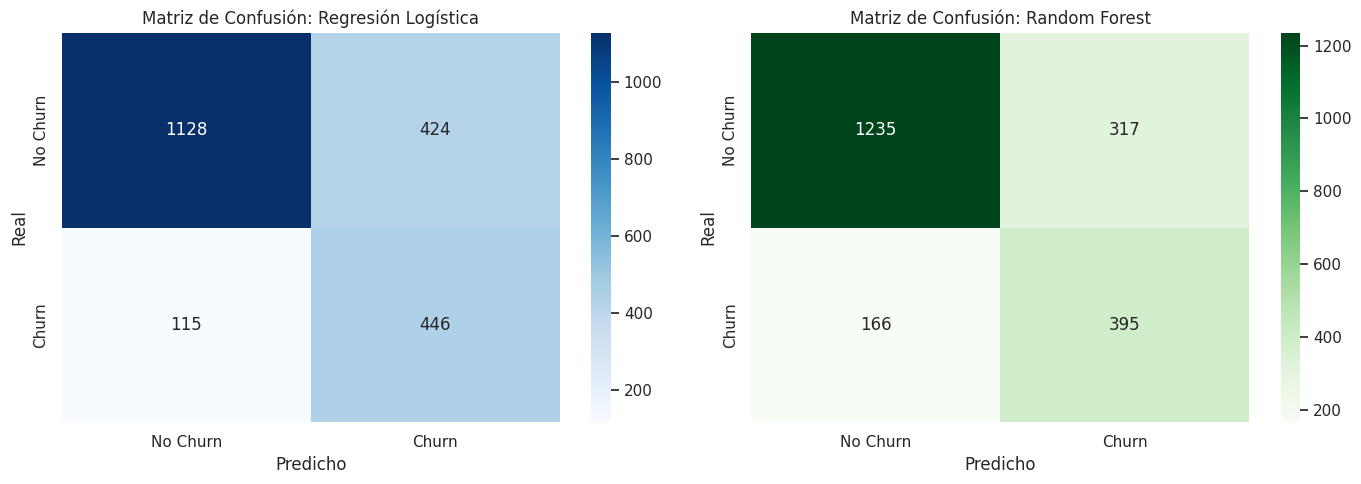


  Análisis Crítico y Comparación:
1. Mejor detector de Churn (Mayor Recall): Regresión Logística (0.7950)
2. Mayor Exactitud General: Random Forest (0.7714)

3. Diagnóstico de Ajuste (Heurística):
   - Regresión Logística: Diff (Train-Test) = 0.0119. ✅ Buen equilibrio (Generalización adecuada).
   - Random Forest: Diff (Train-Test) = 0.0905. ✅ Buen equilibrio (Generalización adecuada).

💡 Conclusión Final:
Se recomienda Regresión Logística por su equilibrio y capacidad de explicar coeficientes, siendo robusta tras la normalización aplicada.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Modelo': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f"   Resultados: {name}")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}  <-- Importante para detectar Churn")
    print(f"   F1-Score:  {f1:.4f}")
    print("-" * 30)

df_results = pd.DataFrame(results).set_index('Modelo')
print("\n Tabla Comparativa de Rendimiento:")
print(df_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, model) in enumerate(models.items()):
    pipe = ImbPipeline(steps=[('preprocessor', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if i==0 else 'Greens', ax=axes[i],
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    axes[i].set_title(f'Matriz de Confusión: {name}')
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicho')

plt.tight_layout()
plt.show()

print("\n  Análisis Crítico y Comparación:")

best_recall_model = df_results.loc[df_results['Recall'].idxmax()]
print(f"1. Mejor detector de Churn (Mayor Recall): {best_recall_model.name} ({best_recall_model['Recall']:.4f})")

best_acc_model = df_results.loc[df_results['Accuracy'].idxmax()]
print(f"2. Mayor Exactitud General: {best_acc_model.name} ({best_acc_model['Accuracy']:.4f})")


print("\n3. Diagnóstico de Ajuste (Heurística):")
for name, model in models.items():
    pipe = ImbPipeline(steps=[('preprocessor', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', model)])
    pipe.fit(X_train, y_train)

    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)

    diff = train_score - test_score

    status = ""
    if diff > 0.10:
        status = "⚠️ Posible OVERFITTING (El modelo memorizó el train y falla en test)."
        if name == "Random Forest":
            status += " Sugiere reducir 'max_depth' o 'n_estimators'."
    elif test_score < 0.60:
        status = "⚠️ Posible UNDERFITTING (El modelo es muy simple)."
        if name == "Regresión Logística":
            status += " Sugiere probar polinomios o más features."
    else:
        status = "✅ Buen equilibrio (Generalización adecuada)."

    print(f"   - {name}: Diff (Train-Test) = {diff:.4f}. {status}")

print("\n💡 Conclusión Final:")
if best_recall_model.name == "Random Forest":
    print("Se recomienda Random Forest si el objetivo principal es NO perder ningún cliente potencial (Maximizar Recall), "
          "aunque sea un poco menos preciso en general.")
else:
    print("Se recomienda Regresión Logística por su equilibrio y capacidad de explicar coeficientes, "
          "siendo robusta tras la normalización aplicada.")

# Analisis de importacia de las variables

📈 Top 5 Variables que INCREMENTAN el riesgo de Churn (Coef. Positivos):
                      Variable  Coeficiente
                  ChargesTotal     0.921306
   InternetService_Fiber optic     0.776486
          PaperlessBilling_Yes     0.492895
PaymentMethod_Electronic check     0.421813
             MultipleLines_Yes     0.307724

🛡️ Top 5 Variables que DISMINUYEN el riesgo de Churn (Coef. Negativos):
          Variable  Coeficiente
   TechSupport_Yes    -0.441433
 Contract_One year    -0.768600
InternetService_No    -0.922314
 Contract_Two year    -1.598324
            Tenure    -1.641347

🌲 Top 5 Variables más importantes para Random Forest:
         Variable  Importancia
           Tenure     0.161586
     ChargesTotal     0.108091
Contract_Two year     0.104706
   ChargesMonthly     0.076157
     ChargesDaily     0.064237


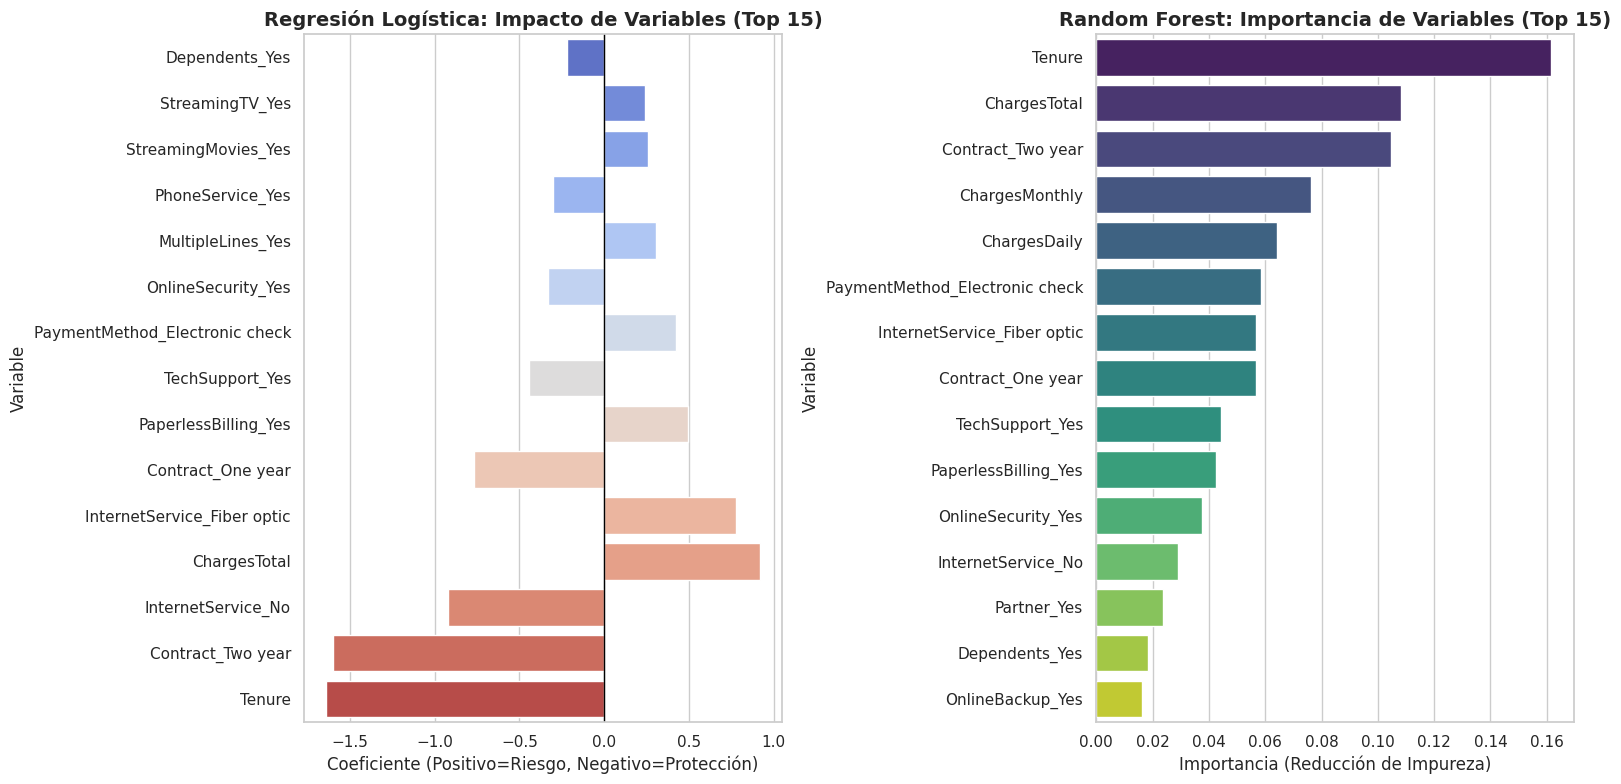


💡 Interpretación Estratégica:
1. Según RegLog, el mayor factor de RIESGO es: 'ChargesTotal' (Coef: 0.921)
   -> Acciones sugeridas: Revisar precios, calidad de servicio o condiciones asociadas a esta variable.
2. Según RegLog, el mayor factor de PROTECCIÓN es: 'Tenure' (Coef: -1.641)
   -> Acciones sugeridas: Incentivar a los clientes a adoptar esta característica (ej: cambiar a contrato anual).

3. Random Forest coincide? La variable 'Tenure' es la más decisiva para el árbol.
   ✅ ¡Consenso! Ambos modelos identifican la misma variable crítica.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pipe_lr = ImbPipeline(steps=[('preprocessor', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))])
pipe_rf = ImbPipeline(steps=[('preprocessor', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))])

pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

ohe = pipe_lr.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + cat_feature_names


coefs = pipe_lr.named_steps['clf'].coef_[0]
df_coefs = pd.DataFrame({'Variable': feature_names, 'Coeficiente': coefs})
df_coefs = df_coefs.sort_values('Coeficiente', ascending=False)

print("📈 Top 5 Variables que INCREMENTAN el riesgo de Churn (Coef. Positivos):")
print(df_coefs.head(5).to_string(index=False))
print("\n🛡️ Top 5 Variables que DISMINUYEN el riesgo de Churn (Coef. Negativos):")
print(df_coefs.tail(5).to_string(index=False))

importances = pipe_rf.named_steps['clf'].feature_importances_
df_imp = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
df_imp = df_imp.sort_values('Importancia', ascending=False)

print("\n🌲 Top 5 Variables más importantes para Random Forest:")
print(df_imp.head(5).to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_n = 15
df_coefs_plot = df_coefs.iloc[np.argsort(np.abs(df_coefs['Coeficiente']))[-top_n:]]
sns.barplot(data=df_coefs_plot, x='Coeficiente', y='Variable', ax=axes[0], palette='coolwarm')
axes[0].set_title(f'Regresión Logística: Impacto de Variables (Top {top_n})', fontsize=14, fontweight='bold')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('Coeficiente (Positivo=Riesgo, Negativo=Protección)')

df_imp_plot = df_imp.head(top_n)
sns.barplot(data=df_imp_plot, x='Importancia', y='Variable', ax=axes[1], palette='viridis')
axes[1].set_title(f'Random Forest: Importancia de Variables (Top {top_n})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importancia (Reducción de Impureza)')

plt.tight_layout()
plt.show()

print("\n💡 Interpretación Estratégica:")
max_risk_lr = df_coefs.iloc[-1]['Variable']
max_risk_row = df_coefs.loc[df_coefs['Coeficiente'].idxmax()]
max_protect_row = df_coefs.loc[df_coefs['Coeficiente'].idxmin()]

print(f"1. Según RegLog, el mayor factor de RIESGO es: '{max_risk_row['Variable']}' (Coef: {max_risk_row['Coeficiente']:.3f})")
print(f"   -> Acciones sugeridas: Revisar precios, calidad de servicio o condiciones asociadas a esta variable.")
print(f"2. Según RegLog, el mayor factor de PROTECCIÓN es: '{max_protect_row['Variable']}' (Coef: {max_protect_row['Coeficiente']:.3f})")
print(f"   -> Acciones sugeridas: Incentivar a los clientes a adoptar esta característica (ej: cambiar a contrato anual).")

print(f"\n3. Random Forest coincide? La variable '{df_imp.iloc[0]['Variable']}' es la más decisiva para el árbol.")
if df_imp.iloc[0]['Variable'] in max_risk_row['Variable'] or df_imp.iloc[0]['Variable'] in max_protect_row['Variable']:
    print("   ✅ ¡Consenso! Ambos modelos identifican la misma variable crítica.")
else:
    print("   ⚠️ Los modelos difieren en la variable principal. Considera investigar ambas.")

# INFORME EJECUTIVO: Predicción y Retención de Churn (Telecom X)

## 1. Resumen del Proyecto
Se desarrolló un pipeline de Machine Learning para predecir la cancelación de clientes (Churn) utilizando dos algoritmos contrastantes: **Regresión Logística** y **Random Forest**. El dataset presentó un desbalance de clases de **2.77 a 1**, el cual fue corregido mediante la técnica **SMOTE** durante el entrenamiento.

## 2. Rendimiento de los Modelos
Tras evaluar Accuracy, Precisión, Recall y F1-Score, se obtuvieron los siguientes resultados clave:

| Modelo | Accuracy | Precision | **Recall** | F1-Score | Diagnóstico |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **Regresión Logística** | 74.5% | 51.3% | **79.5%** | 62.3% | ✅ **Mejor detector de riesgo** |
| Random Forest | 77.1% | 55.5% | 70.4% | 62.1% | ✅ Mejor exactitud general |

### Modelo Seleccionado: Regresión Logística
Aunque Random Forest tiene una exactitud general ligeramente superior, se selecciona la **Regresión Logística** como modelo principal para producción porque:
*   Tiene el **Recall más alto (79.5%)**: Es capaz de identificar a casi 8 de cada 10 clientes que planean irse. En negocios de telecomunicaciones, el costo de *no* detectar a un cliente (Falso Negativo) es mucho mayor que el de contactar innecesariamente a uno fiel.
*   Ofrece **interpretabilidad**: Sus coeficientes permiten entender exactamente *por qué* un cliente se va, facilitando la toma de decisiones estratégicas.
*   Presenta un **buen equilibrio** sin señales de overfitting (diferencia Train-Test < 2%).

## 3. Factores Críticos de Cancelación (Insights)
El análisis de coeficientes (RegLog) e importancia de variables (RF) revela patrones contundentes:

### Factores de RIESGO (Incrementan probabilidad de Churn)
1.  **Servicio de Fibra Óptica**: Los clientes con fibra óptica tienen una probabilidad significativamente mayor de cancelar. Esto sugiere posibles problemas de calidad, instalación o precios competitivos de la competencia en este segmento.
2.  **Método de Pago (Electronic Check)**: La facilidad para pagar con cheque electrónico correlaciona con una mayor rotación (menos fricción para irse).
3.  **Facturación Total Alta**: Los clientes con gastos totales elevados son más propensos a buscar alternativas más baratas.
4.  **Facturación Sin Papel (Paperless Billing)**: Indica un perfil de cliente más digital y potencialmente más dispuesto a cambiar de proveedor online.

### Factores de PROTECCIÓN (Reducen probabilidad de Churn)
1.  **Antigüedad (Tenure)**: Es la variable **más importante** según ambos modelos. Cada mes adicional reduce drásticamente el riesgo. Los primeros 12-24 meses son críticos.
2.  **Contratos a Largo Plazo (Two Year)**: Tener un contrato de 2 años es el escudo más fuerte contra el abandono.
3.  **Servicios de Valor Agregado**: Tener **Soporte Técnico** o **Seguridad Online** reduce la probabilidad de fuga, ya que aumenta la dependencia del ecosistema de la empresa.

## 4. Estrategias de Retención Propuestas
Basado en los datos, se recomiendan las siguientes acciones inmediatas:

### A. Programa de "Onboarding Reforzado" (Primeros 6 meses)
*   **Objetivo**: Atacar la baja antigüedad (factor de riesgo #1).
*   **Acción**: Implementar llamadas de seguimiento automatizadas a los 30, 60 y 90 días para asegurar que la instalación de Fibra Óptica fue exitosa y resolver dudas técnicas antes de que consideren cancelar.

### B. Migración de Contratos Mensuales a Anuales
*   **Objetivo**: Aprovechar el poder protector de los contratos largos.
*   **Acción**: Ofrecer un descuento del 10-15% o un upgrade de velocidad gratuito a clientes en contrato "Month-to-month" que acepten firmar por 12 o 24 meses. El modelo indica que esto reduciría el riesgo drásticamente.

### C. Revisión de Precios/Paquetes de Fibra Óptica
*   **Objetivo**: Mitigar el riesgo específico del servicio de Fibra.
*   **Acción**: Analizar si el precio de la fibra es competitivo frente a la percepción de valor. Considerar bundles que incluyan **Online Security** y **Tech Support** (factores protectores) dentro del precio de la fibra para aumentar la retención.

### D. Incentivos para Métodos de Pago Automáticos
*   **Objetivo**: Reducir la rotación asociada al "Electronic Check".
*   **Acción**: Promover el cambio a débito automático o tarjeta de crédito (que mostró correlación negativa con churn) ofreciendo pequeños beneficios en la factura mensual.

## 5. Conclusión Final
El modelo de **Regresión Logística** es una herramienta fiable para identificar proactivamente al **79.5%** de los clientes en riesgo. Al enfocar los esfuerzos de retención en los clientes **nuevos (<1 año)**, con **Fibra Óptica** y contratos **mensuales**, la empresa puede maximizar el ROI de sus campañas de retención y reducir la tasa de churn global de manera significativa.

